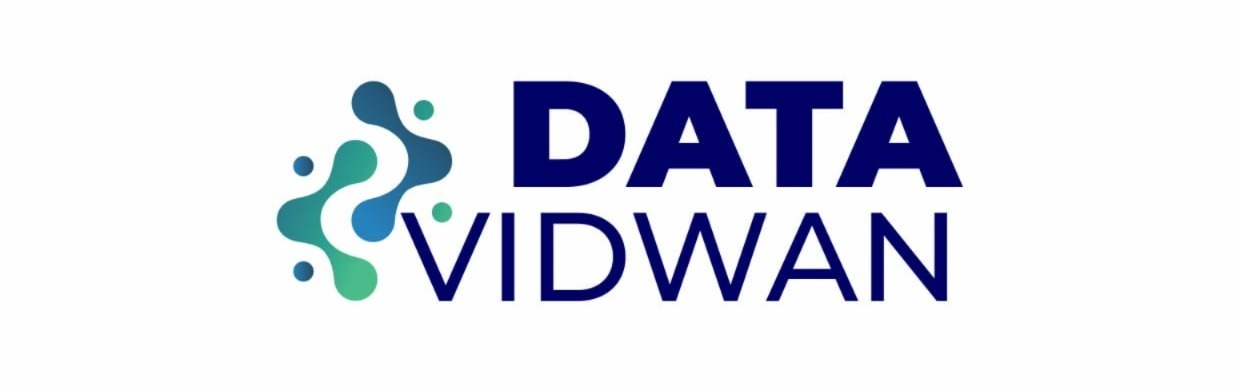

# **Decision Tree Regression**

- Decision Tree Regression is a supervised learning algorithm used to predict continuous numerical values by splitting the data into smaller and smaller subsets based on feature conditions. It builds a tree-like model where each internal node represents a condition on a feature, each branch represents an outcome of that condition, and each leaf node holds the final predicted value. It uses a concept called recursive partitioning, where the dataset is divided into regions that are as homogeneous as possible in terms of the target variable.



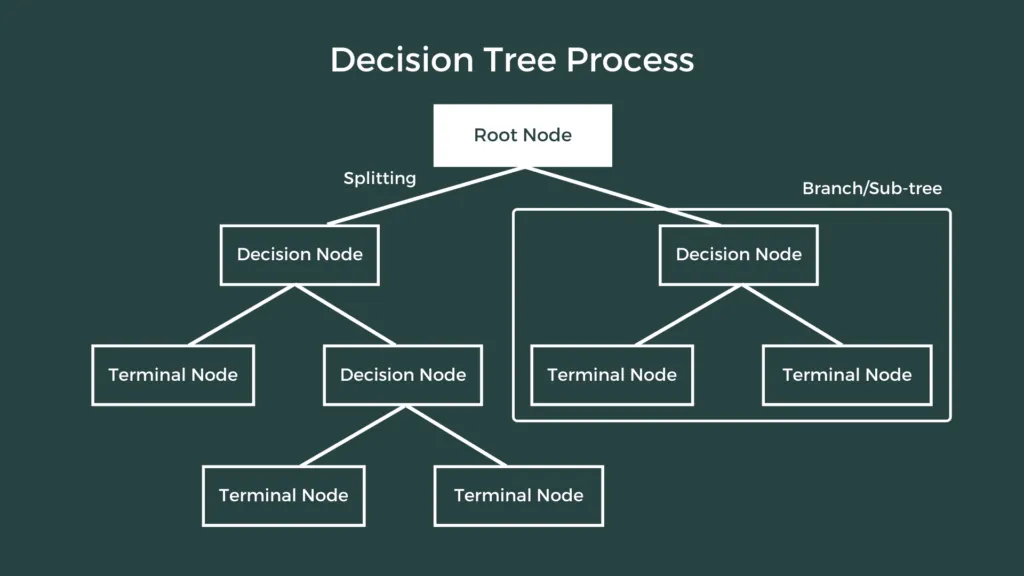

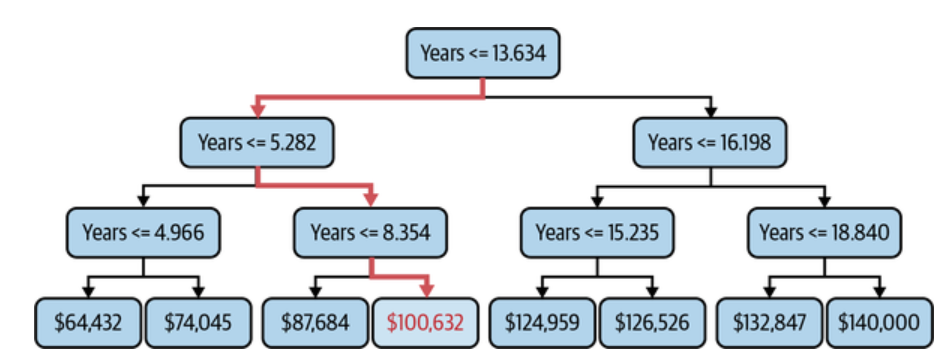

**Why We Use Decision Tree Regression**

- It can model non-linear relationships very effectively.
- Handles both numerical and categorical features without the need for scaling.
- Works well for interpretable models, you can visualize the tree to understand decisions.
- Captures complex patterns and interactions between features.

**Where it is used(Application)**
- **Finance:** Predicting stock prices or credit risk.
- **Real Estate:** Estimating property prices based on features like area, location, and rooms.
- **Marketing:** Forecasting sales or customer spending.
- **Manufacturing:** Predicting production output or machine performance.

**Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**Load Dataset**

In [ ]:
# Step 2: Upload CSV in Colab and load it (no io module used)
from google.colab import files
uploaded = files.upload()

Saving decision_tree.csv to decision_tree.csv


In [ ]:
df = pd.read_csv("houce_price.csv")
df.head()

,Area_sqft,Bedrooms,Bathrooms,Location_Rating,Age_of_House,Price
0,1660,1,4,5,19,247494
1,2094,3,2,8,22,313942
2,1930,4,3,4,15,252634
3,1895,4,2,4,10,262503
4,2438,1,4,5,22,324342


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Area_sqft        3000 non-null   int64
 1   Bedrooms         3000 non-null   int64
 2   Bathrooms        3000 non-null   int64
 3   Location_Rating  3000 non-null   int64
 4   Age_of_House     3000 non-null   int64
 5   Price            3000 non-null   int64
dtypes: int64(6)
memory usage: 140.8 KB


,Area_sqft,Bedrooms,Bathrooms,Location_Rating,Age_of_House,Price
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2147.349000,3.025667,2.471333,5.559667,15.076667,298662.567000
std,768.716412,1.414334,1.108567,2.926425,8.211654,86190.295723
min,801.000000,1.000000,1.000000,1.000000,1.000000,71242.000000
25%,1496.750000,2.000000,2.000000,3.000000,8.000000,237072.500000
50%,2137.000000,3.000000,2.000000,6.000000,15.000000,299388.500000
75%,2803.000000,4.000000,3.000000,8.000000,22.000000,362111.750000
max,3497.000000,5.000000,4.000000,10.000000,29.000000,512113.000000


**Separate features (X) and target (y)**

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

**Split data into training and testing sets**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Decision Tree Regressor**

In [ ]:
model = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=4,
                      random_state=42)

**Model Evaluation**

In [ ]:
pred = model.predict(X_test)

In [ ]:
print("R² Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R² Score: 0.9579791610629163
MAE: 13861.254567460319
MSE: 313277637.96325636
RMSE: 17699.650786477578


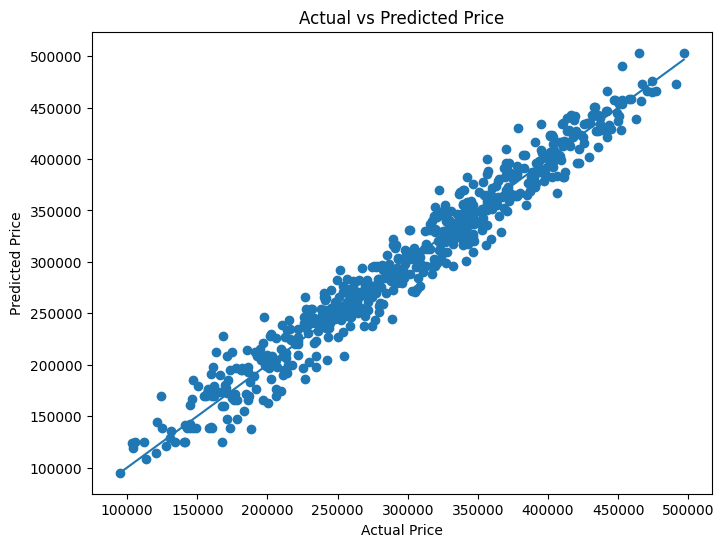

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

**Prediction**

In [ ]:
new_data = pd.DataFrame({
    "Area_sqft":[1660],
    "Bedrooms":[1],
    "Bathrooms":[4],
    "Location_Rating":[5],
    "Age_of_House":[19]
})

result = model.predict(new_data)
print("Predicted Price:", result[0])

Predicted Price: 252285.66666666666


**Final Summary:**

We used Decision Tree Regression because our dataset has non-linear, rule-based patterns that involve sudden jumps and conditional relationships. Decision Trees can naturally handle these complex patterns, while Linear Regression assumes a simple straight-line relationship, which does not fit our data.